# **Data Engineering**

As part of the credit risk modelling process, data transformation plays a critical role in ensuring inputs are accurate, interpretable, and fit-for-purpose. This section outlines how raw and integrated data from the **Model Data Store (MDS)** are systematically transformed into **Model-Ready Data (MRD)** to support development of regulatory models for both IFRS 9 and Advanced IRB (A-IRB) frameworks.

## 🔍 **Purpose of the MDS**

The Model Data Store (MDS) serves as a consolidated and reconciled repository of historical internal and external credit data, and acts as the foundational dataset for all regulatory model development and monitoring. The MDS includes transactional, behavioural, and reference data at the account, customer, and product level. It has been subject to data quality validation and reconciliation processes against core IT systems. These include:
- Reconciliation to general ledger balances and servicing systems;
- Data quality reviews to ensure accuracy and internal consistency (e.g., checking for orphan records, missing values, illogical transitions).

<https://www.kaggle.com/competitions/home-credit-default-risk/data>

In [1]:
%load_ext autoreload 
%autoreload 2 

In [2]:
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import duckdb as dd
import seaborn as sns
import matplotlib.pyplot as plt

from config import HOME_CREDIT_DATA_DIR, DATABASE_DIR, HOME_CREDIT_DB
from const import  APPLICATION_DATE, DEFAULT_THRESHOLD , WRITE_OFF_THRESHOLD, PROBATION_PERIOD

2025-09-22 21:39:20.459 | INFO     | config:<module>:11 - PROJ_ROOT path is: C:\Users\mario\OneDrive\Documents\Education\guide_repo


In [7]:
os.chdir(DATABASE_DIR)
con = dd.connect(HOME_CREDIT_DB)
con

In [17]:
os.chdir(HOME_CREDIT_DATA_DIR)
files_no_ext = [file.replace(".parquet", "") for file in glob.glob("*.parquet")]

print(files_no_ext)

['application_test', 'application_train', 'bureau', 'bureau_balance', 'credit_card_balance', 'installments_payments', 'pos_cash_balance', 'previous_application']


In [18]:
FILE_PATH = Path(HOME_CREDIT_DATA_DIR).as_posix()
print(FILE_PATH)

C:/Users/mario/OneDrive/Documents/Education/guide_repo/data/raw/kaggle/home_credit_group


In [19]:
for INPUT_FILE in files_no_ext:
    query = f"""
        CREATE OR REPLACE TABLE {INPUT_FILE} AS
        SELECT * FROM "{FILE_PATH}/{INPUT_FILE}.parquet"
    """

    con.execute(query)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [20]:
print(con.sql('SHOW ALL TABLES'))

┌─────────────────┬─────────┬───────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [21]:
con.close()

## ⚙️ **Steps to Create Model-Ready Data (MRD)**

The MRD is derived from the MDS through a series of structured data preparation steps aimed at engineering variables, flagging modelling events, and applying business rules. This process ensures each record represents a valid and usable snapshot for statistical modelling purposes.

In [22]:
os.chdir(DATABASE_DIR)
con = dd.connect(HOME_CREDIT_DB)

### **Behavioural Indicator Construction (12-Month Horizon)**

To support behavioural segmentation and model feature creation, the following account history indicators are engineered over trailing observation windows:
- Months In Arrears/DPD Buckets: Mapping days past due (e.g., 0, 1–30, 31–60, etc.) into categorical delinquency stages.
- Instant Default: Defined according to regulatory default (e.g., >90 DPD or unlikely-to-pay);
- Write-off (WO): Identified via charge-off flags or provisioning rules;
- Dirty Account Indicator: Accounts showing non-performing behaviour but not yet defaulted (e.g., ≥60 DPD);
- Probation Flag: Whether the account defaulted in the previous 12 months;
- Cure Flag: Whether the account is no longer in instant default or in probation;
- In Default Flag: Whether the account is not in cure;
- Observation Outcomes: 12 month observation outcomes of all the indicators/flags
- Transactor Flag: Indicates if the account has shown signs of repayment activity (i.e., not revolving) in the past 6 months;
- Inactivity Flag: True if no customer-initiated activity for 4+ months;

#### **Loan Term Column**

In [34]:
query = """
    ALTER TABLE credit_card_balance
    DROP COLUMN LOAN_TERM 
"""
con.execute(query)

query = """
   ALTER TABLE credit_card_balance
   ADD COLUMN LOAN_TERM INTEGER;
"""
con.execute(query)

query = f"""
   WITH loan_terms AS (
      SELECT
         SK_ID_CURR,
         SK_ID_PREV,
         MONTHS_BALANCE,
         ROW_NUMBER() OVER (
               PARTITION BY SK_ID_CURR, SK_ID_PREV
               ORDER BY MONTHS_BALANCE
         ) AS loan_term
      FROM credit_card_balance
   )
   
   UPDATE credit_card_balance AS ccb
   SET LOAN_TERM = lt.loan_term
   FROM loan_terms lt
   WHERE ccb.SK_ID_CURR = lt.SK_ID_CURR
   AND ccb.SK_ID_PREV = lt.SK_ID_PREV
   AND ccb.MONTHS_BALANCE = lt.MONTHS_BALANCE;
"""

con.execute(query)

#### **Calendar Date Column**

In [35]:
query = """
    ALTER TABLE credit_card_balance
    DROP COLUMN CALENDAR_DATE 
"""
con.execute(query)

query = f"""
   ALTER TABLE credit_card_balance
   ADD COLUMN CALENDAR_DATE DATE;
"""
con.execute(query)

query = f"""
   UPDATE credit_card_balance
   SET CALENDAR_DATE = DATE '{APPLICATION_DATE}' + (INTERVAL '1 month' * MONTHS_BALANCE);
"""

con.execute(query)

#### **Arrears Column**

In [36]:
query = """
    ALTER TABLE credit_card_balance
    DROP COLUMN MONTHS_IN_ARREARS 
"""
con.execute(query)

query = """
    ALTER TABLE credit_card_balance
    ADD COLUMN MONTHS_IN_ARREARS INT DEFAULT 0;
"""
con.execute(query)

query = """
    UPDATE credit_card_balance
    SET MONTHS_IN_ARREARS = ROUND(SK_DPD / 30, 0)
"""
con.execute(query)

#### **Instant Default Indicator Column**

In [37]:
query = """
    ALTER TABLE credit_card_balance
    DROP COLUMN INSTANT_DEFAULT_INDICATOR 
"""
con.execute(query)

query = """
    ALTER TABLE credit_card_balance
    ADD COLUMN INSTANT_DEFAULT_INDICATOR BOOLEAN DEFAULT FALSE;
"""
con.execute(query)

query = f"""
    UPDATE credit_card_balance
    SET INSTANT_DEFAULT_INDICATOR = (
        CASE
            WHEN MONTHS_IN_ARREARS >= {DEFAULT_THRESHOLD} THEN TRUE
            ELSE FALSE
        END
    );
"""
con.execute(query)


#### **Default Date Column**

In [40]:
query = """
    ALTER TABLE credit_card_balance
    DROP COLUMN DEFAULT_DATE 
"""
con.execute(query)

query = """
    ALTER TABLE credit_card_balance
    ADD COLUMN DEFAULT_DATE DATE DEFAULT NULL;
"""
con.execute(query)

query = f"""
    UPDATE credit_card_balance t1
    SET DEFAULT_DATE = (
        SELECT t2.CALENDAR_DATE 
        FROM credit_card_balance t2
        WHERE t1.SK_ID_CURR = t2.SK_ID_CURR
        AND t1.SK_ID_PREV = t2.SK_ID_PREV
        AND t2.INSTANT_DEFAULT_INDICATOR = TRUE
        ORDER BY t2.CALENDAR_DATE
        LIMIT 1
    );
"""
con.execute(query)


#### **Probation Indicator Column**

In [45]:
query = """
    ALTER TABLE credit_card_balance
    DROP COLUMN PROBATION_INDICATOR
"""
con.execute(query)

query = """
    ALTER TABLE credit_card_balance
    ADD COLUMN PROBATION_INDICATOR BOOLEAN DEFAULT FALSE;
"""
con.execute(query)

query = f"""
    UPDATE credit_card_balance t1
    SET PROBATION_INDICATOR = EXISTS (
        SELECT 1 
        FROM credit_card_balance t2
        WHERE t1.SK_ID_CURR = t2.SK_ID_CURR
        AND t1.SK_ID_PREV = t2.SK_ID_PREV
        AND t2.INSTANT_DEFAULT_INDICATOR = TRUE
        AND t2.LOAN_TERM BETWEEN (t1.LOAN_TERM - {PROBATION_PERIOD}) AND (t1.LOAN_TERM - 1)
    );
"""
con.execute(query)


#### **Cure Indicator Column**

In [47]:
query = """
    ALTER TABLE credit_card_balance
    DROP COLUMN CURE_INDICATOR 
"""
con.execute(query)

query = """
    ALTER TABLE credit_card_balance
    ADD COLUMN CURE_INDICATOR BOOLEAN DEFAULT FALSE;
"""
con.execute(query)

query = f"""
    UPDATE credit_card_balance
    SET CURE_INDICATOR = (
        CASE
            WHEN INSTANT_DEFAULT_INDICATOR = FALSE AND PROBATION_INDICATOR = FALSE THEN TRUE
            ELSE FALSE
        END
    );
"""
con.execute(query)


#### **Default Indicator Column**

In [48]:
query = """
    ALTER TABLE credit_card_balance
    DROP COLUMN DEFAULT_INDICATOR 
"""
con.execute(query)

query = """
    ALTER TABLE credit_card_balance
    ADD COLUMN DEFAULT_INDICATOR BOOLEAN DEFAULT FALSE;
"""
con.execute(query)

query = f"""
    UPDATE credit_card_balance
    SET DEFAULT_INDICATOR = NOT CURE_INDICATOR
"""
con.execute(query)


#### **Write-off Indicator Column**

In [49]:
query = """
    ALTER TABLE credit_card_balance
    DROP COLUMN WO_INDICATOR 
"""
con.execute(query)

query = """
    ALTER TABLE credit_card_balance
    ADD COLUMN WO_INDICATOR BOOLEAN DEFAULT FALSE;
"""
con.execute(query)

query = f"""
    UPDATE credit_card_balance
    SET WO_INDICATOR = (
        CASE
            WHEN MONTHS_IN_ARREARS >= {WRITE_OFF_THRESHOLD} THEN TRUE
            ELSE FALSE
        END
    );
"""
con.execute(query)


#### **12M Outcome Columns**

In [ ]:
col_dict = {
    "12M_DEFAULT_OUTCOME": ["BOOLEAN", 'DEFAULT_INDICATOR'],
    "12M_WO_OUTCOME": ["BOOLEAN", 'WO_INDICATOR'],
    "12M_BALANCE": ["FLOAT", 'AMT_BALANCE']
}

for col, col_values in col_dict.items():
    query = f"""
        ALTER TABLE credit_card_balance
        DROP COLUMN "{col}";
    """
    con.execute(query)

    query = f"""
        ALTER TABLE credit_card_balance
        ADD COLUMN "{col}" {col_values[0]} DEFAULT NULL;
    """
    con.execute(query)

    query = f"""
        WITH def_outcome AS (
        SELECT
            SK_ID_CURR,
            SK_ID_PREV,
            LOAN_TERM,
            LAG({col_values[1]}, 12, NULL) OVER (
                PARTITION BY SK_ID_CURR, SK_ID_PREV
                ORDER BY LOAN_TERM DESC
            ) AS "{col}",
        FROM credit_card_balance
        )
        
        UPDATE credit_card_balance AS ccb
            SET "{col}" = d."{col}"
            FROM def_outcome d
            WHERE ccb.SK_ID_CURR = d.SK_ID_CURR
        AND ccb.SK_ID_PREV = d.SK_ID_PREV
        AND ccb.LOAN_TERM = d.LOAN_TERM;
    """
    con.execute(query)

In [55]:
query = f"""
        SELECT *
        FROM credit_card_balance
        ORDER BY SK_ID_CURR, LOAN_TERM
        LIMIT 10000;
    """

cc_balance_df = con.sql(query).df()
cc_balance_df.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,MONTHS_IN_ARREARS,INSTANT_DEFAULT_INDICATOR,DEFAULT_DATE,PROBATION_INDICATOR,CURE_INDICATOR,DEFAULT_INDICATOR,WO_INDICATOR,12M_DEFAULT_OUTCOME,12M_WO_OUTCOME,12M_BALANCE
0,1489396,100006,-6,0.0,270000,NaN,0.0,NaN,NaN,0.0,...,0,False,NaT,False,True,False,False,<NA>,<NA>,NaN
1,1489396,100006,-5,0.0,270000,NaN,0.0,NaN,NaN,0.0,...,0,False,NaT,False,True,False,False,<NA>,<NA>,NaN
2,1489396,100006,-4,0.0,270000,NaN,0.0,NaN,NaN,0.0,...,0,False,NaT,False,True,False,False,<NA>,<NA>,NaN
3,1489396,100006,-3,0.0,270000,NaN,0.0,NaN,NaN,0.0,...,0,False,NaT,False,True,False,False,<NA>,<NA>,NaN
4,1489396,100006,-2,0.0,270000,NaN,0.0,NaN,NaN,0.0,...,0,False,NaT,False,True,False,False,<NA>,<NA>,NaN


<Axes: xlabel='12m_default_rate', ylabel='Count'>

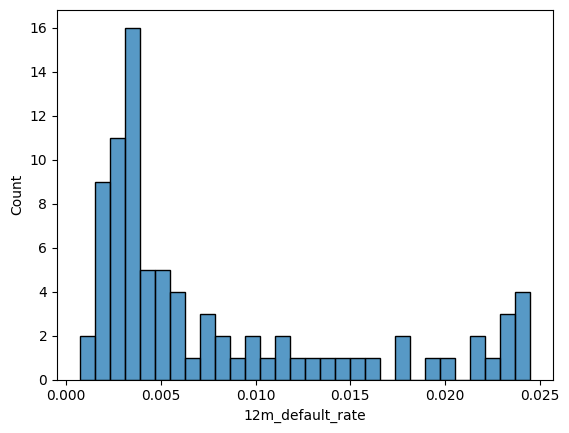

In [53]:
query = f"""
        SELECT 
            CALENDAR_DATE, 
            SUM("12M_DEFAULT_OUTCOME") AS total_defaults, 
            COUNT(*) AS total_count, 
            SUM("12M_BALANCE") AS total_12m_balance, 
            SUM(AMT_BALANCE) AS total_current_balance,
            SUM("12M_WO_OUTCOME") AS total_wo
        FROM credit_card_balance
        WHERE DEFAULT_INDICATOR = 0
        GROUP BY CALENDAR_DATE;
    """

cc_balance_df = con.sql(query).df()
cc_balance_df['12m_default_rate'] = cc_balance_df['total_defaults'] / cc_balance_df['total_count']
cc_balance_df['12m_wo_rate'] = cc_balance_df['total_wo'] / cc_balance_df['total_count']
cc_balance_df['12m_ead'] = cc_balance_df['12m_default_rate'] * cc_balance_df['total_12m_balance']
cc_balance_df['12m_eadf'] = cc_balance_df['12m_ead'] / cc_balance_df['total_current_balance']
sns.histplot(data=cc_balance_df, x='12m_default_rate',  bins=30)

<Axes: xlabel='CALENDAR_DATE', ylabel='12m_default_rate'>

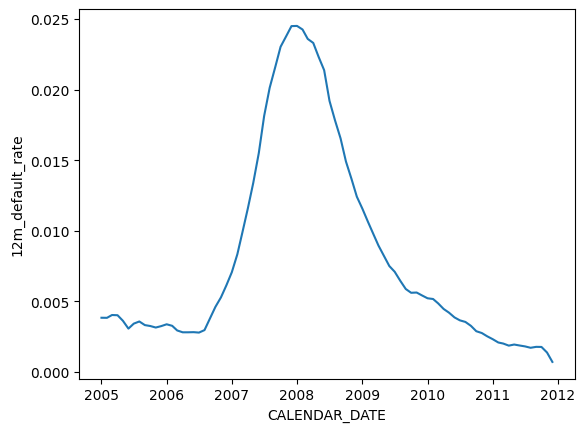

In [54]:
sns.lineplot(data=cc_balance_df, x='CALENDAR_DATE', y='12m_default_rate')

<Axes: xlabel='CALENDAR_DATE', ylabel='12m_ead'>

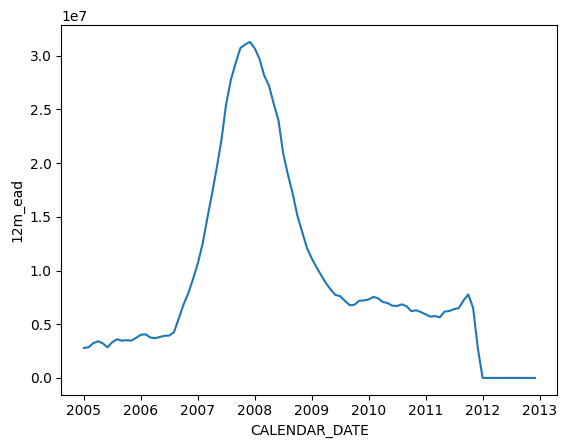

In [37]:
sns.lineplot(data=cc_balance_df, x='CALENDAR_DATE', y='12m_ead')

<Axes: xlabel='CALENDAR_DATE', ylabel='12m_wo_rate'>

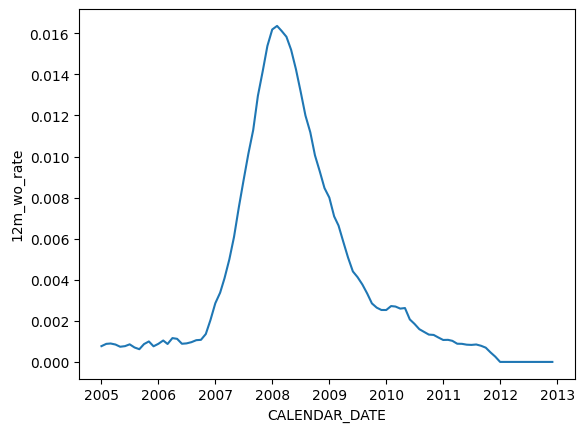

In [40]:
sns.lineplot(data=cc_balance_df, x='CALENDAR_DATE', y='12m_wo_rate')

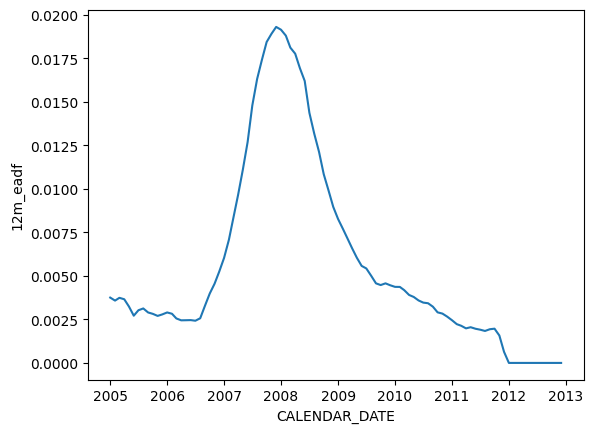

In [17]:
sns.lineplot(data=cc_balance_df, x='CALENDAR_DATE', y='12m_eadf')
plt.show()

In [187]:

query = """
    SELECT column_name, data_type, ordinal_position, column_default, is_nullable,  character_maximum_length
    FROM information_schema.columns
    WHERE table_name = 'credit_card_balance';
"""

con.sql(query)

┌────────────────────────────┬───────────┬──────────────────┬──────────────────────┬─────────────┬──────────────────────────┐
│        column_name         │ data_type │ ordinal_position │    column_default    │ is_nullable │ character_maximum_length │
│          varchar           │  varchar  │      int32       │       varchar        │   varchar   │          int32           │
├────────────────────────────┼───────────┼──────────────────┼──────────────────────┼─────────────┼──────────────────────────┤
│ SK_ID_PREV                 │ BIGINT    │                1 │ NULL                 │ YES         │                     NULL │
│ SK_ID_CURR                 │ BIGINT    │                2 │ NULL                 │ YES         │                     NULL │
│ MONTHS_BALANCE             │ BIGINT    │                3 │ NULL                 │ YES         │                     NULL │
│ AMT_BALANCE                │ DOUBLE    │                4 │ NULL                 │ YES         │                    